# N-BEATS — MA20 Forecast on Synthetic Financial Series

This notebook:
1. Simulates **6 synthetic financial price series** (3 uptrend, 3 downtrend) via Geometric Brownian Motion
2. Computes the **20-period Simple Moving Average (MA20)** for each
3. Trains an **N-BEATS model** per series to forecast the MA20
4. Evaluates with **MAPE, RMSE and MAE** in backtesting


## 1. Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from darts import TimeSeries
from darts.models import NBEATSModel
from darts.metrics import mape, rmse, mae


## 2. Simulate Financial Time Series Data

6 series generated via **Geometric Brownian Motion**:
- **Uptrend A/B/C** — positive daily drift (`mu > 0`)
- **Downtrend A/B/C** — negative daily drift (`mu < 0`)

Formula: $S_t = S_{t-1} \cdot e^{(\mu - \frac{\sigma^2}{2}) + \sigma \epsilon_t}$, where $\epsilon_t \sim \mathcal{N}(0,1)$


In [2]:
def simulate_gbm(S0, mu, sigma, n_periods, seed):
    """Simulate asset prices via Geometric Brownian Motion."""
    np.random.seed(seed)
    log_returns = np.random.normal((mu - 0.5 * sigma**2), sigma, n_periods)
    prices = S0 * np.exp(np.cumsum(log_returns))
    return prices

# --- Configuration ---
N_PERIODS  = 300
MA_WINDOW  = 20
TRAIN_SPLIT = 0.8
INPUT_CHUNK = 30
OUTPUT_CHUNK = 10
N_EPOCHS = 50
START_DATE = "2022-01-01"

dates = pd.date_range(start=START_DATE, periods=N_PERIODS, freq="B")

series_configs = [
    {"name": "Uptrend A",   "S0": 100, "mu":  0.0015, "sigma": 0.020, "seed": 10},
    {"name": "Uptrend B",   "S0":  50, "mu":  0.0022, "sigma": 0.025, "seed": 20},
    {"name": "Uptrend C",   "S0": 200, "mu":  0.0012, "sigma": 0.018, "seed": 30},
    {"name": "Downtrend A", "S0": 100, "mu": -0.0015, "sigma": 0.020, "seed": 40},
    {"name": "Downtrend B", "S0": 150, "mu": -0.0022, "sigma": 0.025, "seed": 50},
    {"name": "Downtrend C", "S0":  80, "mu": -0.0012, "sigma": 0.018, "seed": 60},
]

# Generate price series
all_data = {}
for cfg in series_configs:
    prices = simulate_gbm(cfg["S0"], cfg["mu"], cfg["sigma"], N_PERIODS, cfg["seed"])
    df = pd.DataFrame({"Date": dates, "Price": prices})
    all_data[cfg["name"]] = {"df": df, "config": cfg}

print(f"Generated {len(all_data)} series with {N_PERIODS} periods each.")
for name, data in all_data.items():
    df = data["df"]
    trend = "↑" if data["config"]["mu"] > 0 else "↓"
    print(f"  {trend} {name:15s} | Start: {df['Price'].iloc[0]:7.2f} | End: {df['Price'].iloc[-1]:7.2f}")


Generated 6 series with 300 periods each.
  ↑ Uptrend A       | Start:  102.83 | End:  189.54
  ↑ Uptrend B       | Start:   51.21 | End:   86.99
  ↑ Uptrend C       | Start:  195.70 | End:  261.11
  ↓ Downtrend A     | Start:   98.62 | End:   47.77
  ↓ Downtrend B     | Start:  143.90 | End:   47.25
  ↓ Downtrend C     | Start:   78.58 | End:   48.11


## 3. Calculate 20-Period Moving Averages

In [3]:
for name, data in all_data.items():
    df = data["df"]
    df["MA20"] = df["Price"].rolling(MA_WINDOW).mean()
    data["df"] = df.dropna().reset_index(drop=True)

effective_len = len(next(iter(all_data.values()))["df"])
print(f"Effective series length after MA20 (dropped {MA_WINDOW - 1} NaN rows): {effective_len} periods")


Effective series length after MA20 (dropped 19 NaN rows): 281 periods


## 4. Visualize Raw Series and Moving Averages

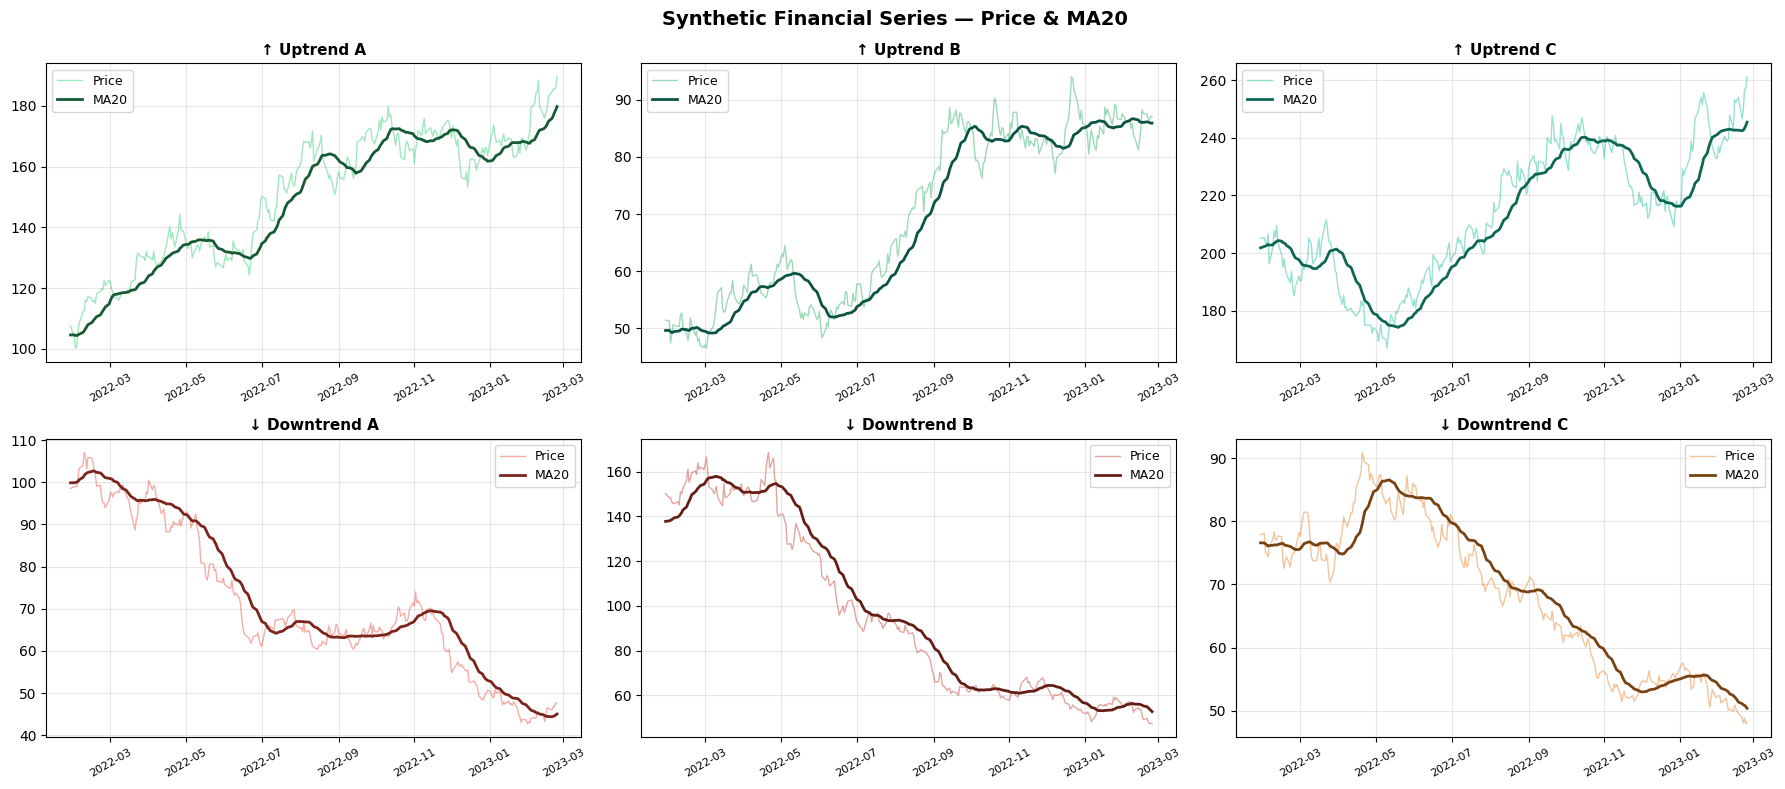

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

price_colors = {
    "Uptrend A": "#2ecc71", "Uptrend B": "#27ae60", "Uptrend C": "#1abc9c",
    "Downtrend A": "#e74c3c", "Downtrend B": "#c0392b", "Downtrend C": "#e67e22",
}
ma_colors = {
    "Uptrend A": "#145a32", "Uptrend B": "#0b5345", "Uptrend C": "#0e6655",
    "Downtrend A": "#7b241c", "Downtrend B": "#641e16", "Downtrend C": "#784212",
}

for idx, (name, data) in enumerate(all_data.items()):
    ax = axes[idx]
    df = data["df"]
    trend = "Uptrend" if data["config"]["mu"] > 0 else "Downtrend"
    arrow = "↑" if trend == "Uptrend" else "↓"

    ax.plot(df["Date"], df["Price"], color=price_colors[name], alpha=0.45, linewidth=1, label="Price")
    ax.plot(df["Date"], df["MA20"], color=ma_colors[name], linewidth=2, label="MA20")
    ax.set_title(f"{arrow} {name}", fontsize=11, fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="x", rotation=30, labelsize=8)

plt.suptitle("Synthetic Financial Series — Price & MA20", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("Financial_Series_Overview.png", dpi=150, bbox_inches="tight")
plt.show()


## 5. Prepare Darts TimeSeries Objects

Convert each MA20 series into a Darts `TimeSeries` and split into train (80%) / test (20%).

In [5]:
darts_series = {}
for name, data in all_data.items():
    df = data["df"]
    ts = TimeSeries.from_dataframe(df, time_col="Date", value_cols="MA20")
    train, test = ts.split_before(TRAIN_SPLIT)
    darts_series[name] = {"ts": ts, "train": train, "test": test}
    print(f"  {name:15s} | Total: {len(ts):4d} | Train: {len(train):4d} | Test: {len(test):4d}")


  Uptrend A       | Total:  281 | Train:  224 | Test:   57
  Uptrend B       | Total:  281 | Train:  224 | Test:   57
  Uptrend C       | Total:  281 | Train:  224 | Test:   57
  Downtrend A     | Total:  281 | Train:  224 | Test:   57
  Downtrend B     | Total:  281 | Train:  224 | Test:   57
  Downtrend C     | Total:  281 | Train:  224 | Test:   57


## 6. Train N-BEATS Model per Series

One independent model per series. Parameters: `input_chunk_length=30`, `output_chunk_length=10`, `n_epochs=50`.


In [6]:
trained_models = {}

for name, data in darts_series.items():
    print(f"\n{'='*55}")
    print(f"  Training N-BEATS → {name}")
    print(f"{'='*55}")
    model = NBEATSModel(
        input_chunk_length=INPUT_CHUNK,
        output_chunk_length=OUTPUT_CHUNK,
        n_epochs=N_EPOCHS,
        random_state=42,
    )
    model.fit(data["train"], verbose=False)
    trained_models[name] = model
    print(f"  Done.")

print("\nAll 6 models trained successfully.")



  Training N-BEATS → Uptrend A


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
C:\Users\Harrison\Documents\Programação\Python\forecasting_lab\.venv\lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
C:\Users\Harrison\Documents\Programação\Python\forecasting_lab\.venv\lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
`Trainer.fit` stopped: `max_epochs=50` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
C:\Users\Harrison\Documents\Programação\Python\forecasting_lab\.venv\lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec)

  Done.

  Training N-BEATS → Uptrend B


`Trainer.fit` stopped: `max_epochs=50` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
C:\Users\Harrison\Documents\Programação\Python\forecasting_lab\.venv\lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
C:\Users\Harrison\Documents\Programação\Python\forecasting_lab\.venv\lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


  Done.

  Training N-BEATS → Uptrend C


...

  Done.

  Training N-BEATS → Downtrend B


`Trainer.fit` stopped: `max_epochs=50` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
C:\Users\Harrison\Documents\Programação\Python\forecasting_lab\.venv\lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
C:\Users\Harrison\Documents\Programação\Python\forecasting_lab\.venv\lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


  Done.

  Training N-BEATS → Downtrend C


`Trainer.fit` stopped: `max_epochs=50` reached.


  Done.

All 6 models trained successfully.


## 7. Backtest and Evaluate Each Series

In [7]:
backtest_results = {}
metrics_rows = []

for name, model in trained_models.items():
    ts = darts_series[name]["ts"]
    metrics = model.backtest(
        ts,
        start=TRAIN_SPLIT,
        forecast_horizon=OUTPUT_CHUNK,
        stride=1,
        retrain=False,
        verbose=False,
        metric=[mape, rmse, mae],
    )
    hist_fc = model.historical_forecasts(
        ts,
        start=TRAIN_SPLIT,
        forecast_horizon=OUTPUT_CHUNK,
        stride=OUTPUT_CHUNK,  # non-overlapping windows for cleaner plot
        retrain=False,
        verbose=False,
    )
    backtest_results[name] = {"metrics": metrics, "historical_forecasts": hist_fc}
    trend = "Uptrend" if "Uptrend" in name else "Downtrend"
    metrics_rows.append({
        "Series": name,
        "Trend": trend,
        "MAPE (%)": round(metrics[0], 3),
        "RMSE": round(metrics[1], 3),
        "MAE": round(metrics[2], 3),
    })

metrics_df = pd.DataFrame(metrics_rows)
print("=" * 68)
print("N-BEATS Backtest Metrics — MA20 Forecast")
print("=" * 68)
print(metrics_df.to_string(index=False))
print("=" * 68)
print(f"\nMean MAPE : {metrics_df['MAPE (%)'].mean():.3f}%")
print(f"Mean RMSE : {metrics_df['RMSE'].mean():.3f}")
print(f"Mean MAE  : {metrics_df['MAE'].mean():.3f}")


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
G

N-BEATS Backtest Metrics — MA20 Forecast
     Series     Trend  MAPE (%)  RMSE   MAE
  Uptrend A   Uptrend     1.979 3.515 3.282
  Uptrend B   Uptrend     1.825 1.668 1.556
  Uptrend C   Uptrend     2.832 6.999 6.550
Downtrend A Downtrend     2.669 1.486 1.409
Downtrend B Downtrend     4.300 2.646 2.427
Downtrend C Downtrend     2.838 1.614 1.525

Mean MAPE : 2.741%
Mean RMSE : 2.988
Mean MAE  : 2.791


## 8. Plot Forecast Results for All Series

C:\Users\Harrison\Documents\Programação\Python\forecasting_lab\.venv\lib\site-packages\pandas\plotting\_matplotlib\core.py:981: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)
C:\Users\Harrison\Documents\Programação\Python\forecasting_lab\.venv\lib\site-packages\pandas\plotting\_matplotlib\core.py:981: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)
C:\Users\Harrison\Documents\Programação\Python\forecasting_lab\.venv\lib\site-packages\pandas\plotting\_matplotlib\core.py:981: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)
C:\Users\Harrison\Documents\Programação\Python\forecasting_lab\.venv\lib\site-packages\pandas\plotting\_matplotlib\core.py:981: UserWarning: This axis already has a converter set and is updating to a

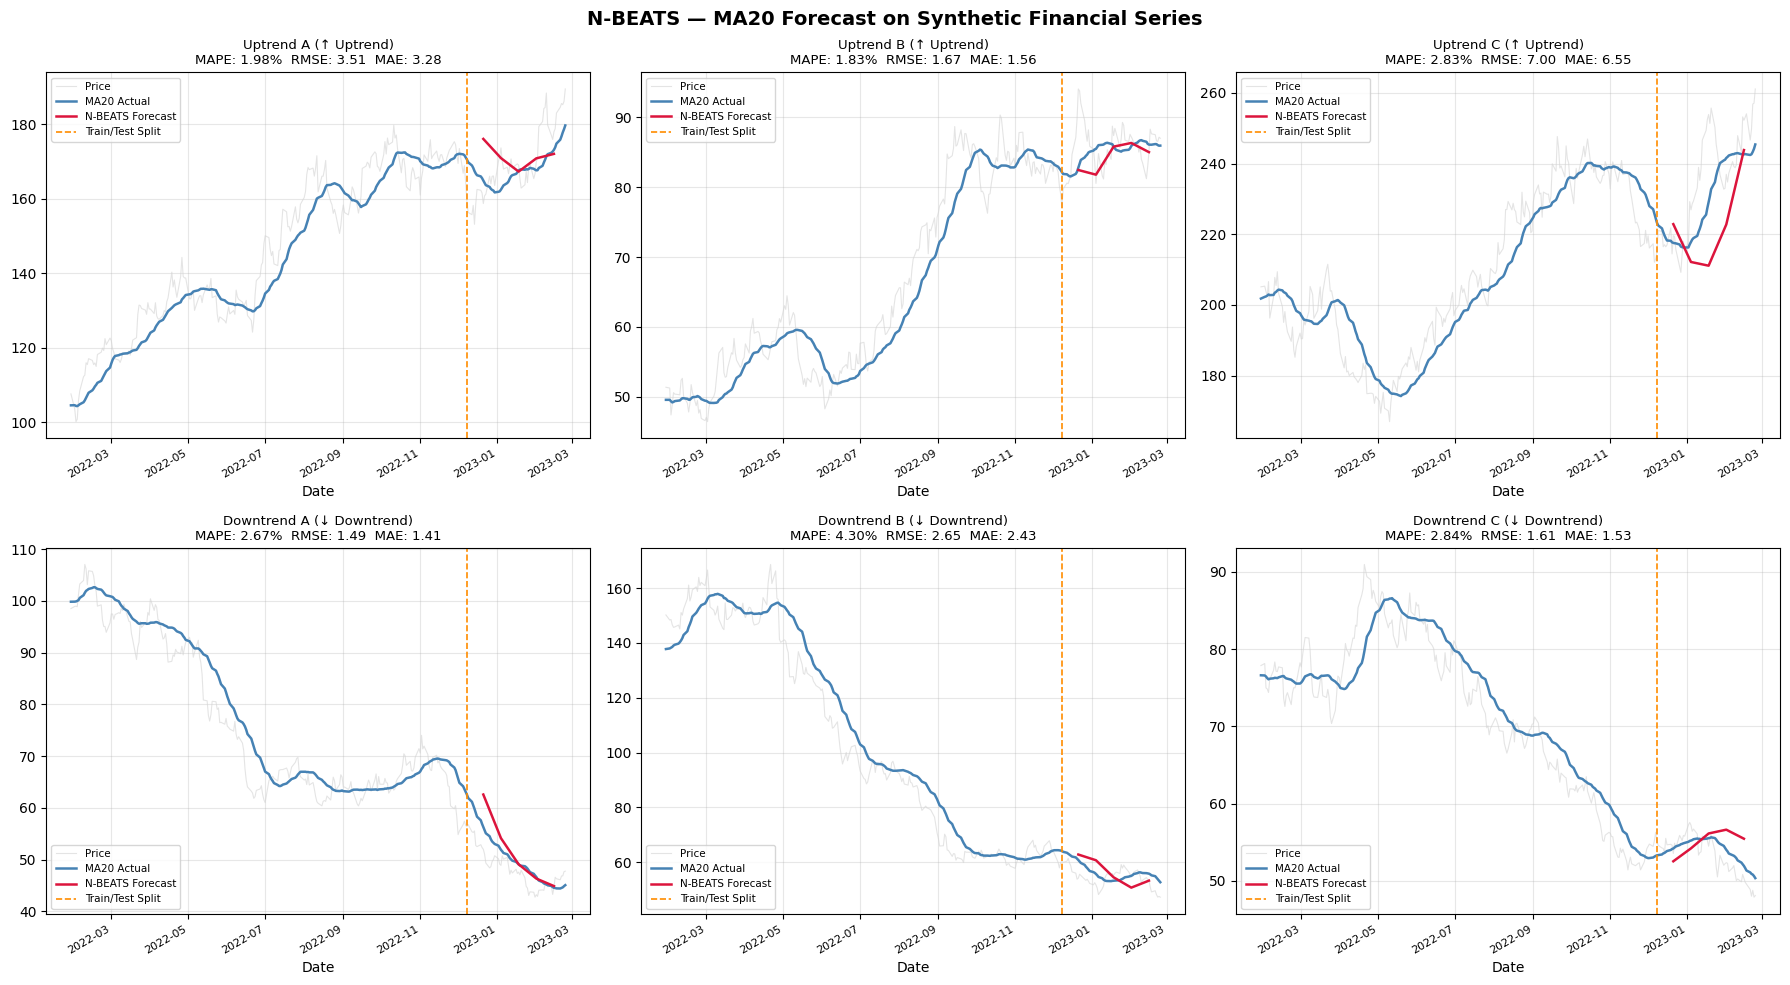

Figure saved as NBEATS_Financial_Forecast.png


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (name, res) in enumerate(backtest_results.items()):
    ax = axes[idx]
    df = all_data[name]["df"]
    ts = darts_series[name]["ts"]
    mape_val, rmse_val, mae_val = res["metrics"]
    trend_label = "↑ Uptrend" if "Uptrend" in name else "↓ Downtrend"

    # Raw price (background)
    ax.plot(df["Date"], df["Price"], color="lightgray", linewidth=0.8, alpha=0.6, label="Price")
    # MA20 actual
    ax.plot(df["Date"], df["MA20"], color="steelblue", linewidth=1.8, label="MA20 Actual")
    # N-BEATS forecasts
    res["historical_forecasts"].plot(ax=ax, label="N-BEATS Forecast", color="crimson", linewidth=1.8)

    # Train/test split line
    split_date = df["Date"].iloc[int(len(df) * TRAIN_SPLIT)]
    ax.axvline(x=split_date, color="darkorange", linestyle="--", linewidth=1.2, label="Train/Test Split")

    ax.set_title(
        f"{name} ({trend_label})\nMAPE: {mape_val:.2f}%  RMSE: {rmse_val:.2f}  MAE: {mae_val:.2f}",
        fontsize=9.5,
    )
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7.5)
    ax.tick_params(axis="x", rotation=30, labelsize=8)

plt.suptitle("N-BEATS — MA20 Forecast on Synthetic Financial Series", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("NBEATS_Financial_Forecast.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved as NBEATS_Financial_Forecast.png")
